# AII 600. Lab 2

Due before class, 9 September 2026.

Upload this notebook on Canvas, with every code cell executed and the output left in. Credit is on-time submission. I do not mark the lab.

Python kernel. R is allowed: switch to an R kernel and rewrite the code cells. Ask the tutor to translate `check`.

This is the material from joint tables through the confusion matrix. We did not stop for the in-class checks; they are here, plus the new-product test and a simulation of Monty Hall. Exercises 1 through 8 are this week's lecture. Exercise 9 is a stretch: a count of wins in a fixed number of games, using a distribution we name on 9 September. Look the pmf up now so that hour is review, not first contact. Work each numeric question on paper first, then type the number. You may use Python as a calculator. Written cells have no check; they are for you.

The test cell under each answer is the grader. It does not contain the number. Fill the answer cell, run it, then run the test cell. If it prints `ok`, that name is right to six decimals. If it says a name is not right, rework that quantity; the cell will not tell you the value. Type an expression (`0.14/0.24`, `36/316`) rather than a rounded decimal. The midterm has no test cell.

These are not a substitute for a cheat sheet. After you finish, copy the formulas you actually used onto one.


## How an exercise is built

Run the next cell once. It defines `check`. Each numeric exercise then has two code cells. The first is yours: replace every `None`. The second calls `check`. A line that prints `ok` passed. Leave the output in the notebook.

Do not delete the variable names. You can add scratch cells above an answer cell if you want to compute in public.

Several cells are real Python, not a calculator. You will index a table, write a function, and run a loop. The stretch at the end also uses `numpy` and `matplotlib`. Ask the tutor for syntax; do the probability yourself.


In [23]:
from hashlib import sha256

def check(name, value, expected, ndigits=6):
    if value is None:
        raise AssertionError(f"replace None for {name}")
    s = f"{round(float(value), ndigits):.{ndigits}f}"
    got = sha256(f"aii600-lab2|{name}|{s}".encode()).hexdigest()[:16]
    assert got == expected, f"{name} is not right"
    print("ok ", name)


## Exercise 1: joint, marginal, conditional

A wealth-management team wants to pitch a "wellbeing" product only to top-salary clients. Last year's book:

| Salary $X$ \ Happiness $Y$ | 0 | 1 | 2 |
|---|---|---|---|
| 0 | 0.03 | 0.12 | 0.07 |
| 1 | 0.02 | 0.13 | 0.11 |
| 2 | 0.01 | 0.13 | 0.14 |
| 3 | 0.01 | 0.09 | 0.14 |

Each cell is a joint probability $P(X=x,Y=y)$. Work the four items on paper so you know which row and column to touch. Then compute them from `joint` below. Rows are $X=0,1,2,3$. Columns are $Y=0,1,2$. `joint[3][2]` is the bottom-right cell. A column sum is `sum(row[2] for row in joint)`. A row sum is `sum(joint[3])`.

1. $P(X=3,Y=2)$. Share of the book that is both top-salary and high-happiness.
2. $P(Y=2)$ and $P(X=3)$.
3. $P(Y=2\mid X=3)$ and $P(X=3\mid Y=2)$. Same cell, two denominators.
4. Is $Y$ independent of $X$? Compare $P(Y=2\mid X=3)$ to $P(Y=2)$. Enter `0` if not independent, `1` if independent.


In [24]:
# rows X = 0,1,2,3; columns Y = 0,1,2
joint = [
    [0.03, 0.12, 0.07],
    [0.02, 0.13, 0.11],
    [0.01, 0.13, 0.14],
    [0.01, 0.09, 0.14],
]
p_both = joint[3][2]          # P(X=3, Y=2) from joint
p_high = sum(row[2] for row in joint)          # P(Y=2), a column sum
p_top = sum(joint[3])           # P(X=3), a row sum
p_high_given_top = p_both / p_top
p_top_given_high = p_both / p_high
independent = 0     # 0 or 1
p_both, p_high, p_top, p_high_given_top, p_top_given_high, independent


(0.14, 0.46, 0.24000000000000002, 0.5833333333333334, 0.30434782608695654, 0)

In [25]:
check("p_both", p_both, "10cf2f3f7591d9dc")
check("p_high", p_high, "32d8fcd2e9f00da8")
check("p_top", p_top, "ee084068f73a1470")
check("p_high_given_top", p_high_given_top, "8935c251e15ee36b")
check("p_top_given_high", p_top_given_high, "c01b5b7c83a69ba9")
check("independent", independent, "5bb7176db7bdcad5")
print("ok  exercise 1")


ok  p_both
ok  p_high
ok  p_top
ok  p_high_given_top
ok  p_top_given_high
ok  independent
ok  exercise 1


### Written


The deck says "our highest earners are the happy ones," so they want to restrict the product to the top salary band. Using the five numbers above: is that mixing a slice with the whole book? Who would the pitch miss, and who would it bother?

**Q1: Yes, becuase there are happy people (Y=2) at salary ranges other than the top.**  
**Q2: The pitch would miss the people who report high happiness at different salary ranges. ~32% of the people.**  
**Q3: It would bother those who are top earners but do NOT report highest happieness. ~10% of the people.**


## Exercise 2: a mix of two salespeople

You split Saturday's leads: half to Tortoise, half to Hare. $P=\tfrac12 T+\tfrac12 H$ is the average per rep, not the floor total.

Same means as in the notes: $E(T)=E(H)=1.5$, $Var(T)=0.25$, $Var(H)=2.25$. When one has a good day the other has a bad one: $Cov(T,H)=-0.75$.

What do you expect that average to be? How jumpy is it compared with giving every lead to Tortoise? Compute $E(P)$ and $Var(P)$ on paper from

$$
E(aX+bY)=aE(X)+bE(Y),\qquad
Var(aX+bY)=a^2Var(X)+b^2Var(Y)+2ab\,Cov(X,Y).
$$


In [26]:
.5*1.5 + .5*1.5
.5**2*.25 + .5**2*2.25 + 2*.5*.5*-.75

0.25

In [27]:
e_p = 1.5
var_p = .25
e_p, var_p


(1.5, 0.25)

In [28]:
check("e_p", e_p, "c57b4d6e97239fc1")
check("var_p", var_p, "249f965626b23dfe")
print("ok  exercise 2")


ok  e_p
ok  var_p
ok  exercise 2


## Exercise 3: holes you can see

You brief tonight. Someone counted 36 cockpit holes on the planes that came back and wants cockpit armor because "that is a lot of damage."

From the table: 316 returned. Cockpit 36 returned, 21 down. Engine 29 returned, 31 down.

1. Among the planes you can see, how common is cockpit damage?
2. Among planes that took a cockpit hit, how often did the plane come back? Same question for engine.
3. In the written cell: which of those numbers goes in the brief? One sentence on what $36/316$ is actually describing.


In [29]:
p_cockpit_among_returned = 36/316
p_return_given_cockpit = 36/57
p_return_given_engine = 29/60
p_cockpit_among_returned, p_return_given_cockpit, p_return_given_engine


(0.11392405063291139, 0.631578947368421, 0.48333333333333334)

In [30]:
check("p_cockpit_among_returned", p_cockpit_among_returned, "8a51f0a5109cd380")
check("p_return_given_cockpit", p_return_given_cockpit, "99ecc5a9a3e8ad92")
check("p_return_given_engine", p_return_given_engine, "fafabd3000cff9bb")
print("ok  exercise 3")


ok  p_cockpit_among_returned
ok  p_return_given_cockpit
ok  p_return_given_engine
ok  exercise 3


Which number goes in the brief, and what is $36/316$ actually describing?

**Q1: The number that goes in the brief should be p_return_given_engine since less than half the planes that had damage to the engine came back.**  
**Q2: 36/316 is actually describing the number of planes that had damage to the cockpit and still made it home.**


## Exercise 4: the island

A man is arrested on an island of 1,001 people. The crime-scene trait occurs in 1 in 10,000 people; it matches him. Uniform prior. $P(\text{match}\mid\text{guilty})=1$.

The prosecutor tells the jury: "The match probability is 1 in 10,000, so there is a 99.99% chance he is guilty."

You are the defense statistician. On paper:

1. Prior odds he is innocent, $O(I)$.
2. Posterior odds $O(I\mid E)$.
3. $P(\text{guilty}\mid\text{match})$.

Then one sentence in the written cell you would actually say to the jury.


In [31]:
prior_odds_innocent = 1000
posterior_odds_innocent = .1
p_guilty_given_match = 1/(1+posterior_odds_innocent)
prior_odds_innocent, posterior_odds_innocent, p_guilty_given_match


(1000, 0.1, 0.9090909090909091)

In [32]:
check("prior_odds_innocent", prior_odds_innocent, "74d2381fb25b1974")
check("posterior_odds_innocent", posterior_odds_innocent, "638d8c52c4a185d7")
check("p_guilty_given_match", p_guilty_given_match, "2908db0ce3f0398d")
print("ok  exercise 4")


ok  prior_odds_innocent
ok  posterior_odds_innocent
ok  p_guilty_given_match
ok  exercise 4


One sentence to the jury.

**1 in 10,000 says of 10,000 people 1 matches the trait. Because we already know the suspect matches, the number you need to know is the probability that someone matches the trait is guilty. This number is 90% NOT 99.99%.**


## Exercise 5: three prisoners, then Monty Hall

Uniform prior: $P(\text{Pardon})=\tfrac13$ for $A$, $B$, and $C$. The warden will not name $A$. If $A$ is pardoned, the warden names $B$ or $C$ at random. The warden says $WB$: $B$ will be executed.

On paper, using Bayes:

1. $P(A\mid WB)$
2. $C$ overhears. $P(C\mid WB)$

Did the warden's news change $A$'s chance?

The same update with doors is Monty Hall. You pick door $A$. Monty, who never opens the car and never opens your door, opens $B$ (a goat). Let $MB$ be that event.

3. $P(\text{car behind }A\mid MB)$ and $P(\text{car behind }C\mid MB)$. If you already have the prisoners, do not redo the algebra; name the correspondence and copy the two numbers.

Then simulate the game. At least 10,000 independent plays. Each play: the car is equally likely behind 0, 1, or 2; you always pick door 0 (the labels are arbitrary); Monty opens a goat door that is not your pick, choosing at random if he has two choices; staying means keeping door 0; switching means taking the remaining closed door. Record the win rates of stay and of switch.


In [33]:
p_a_given_wb = 1/3
p_c_given_wb = 2/3
p_stay = p_a_given_wb       # P(car behind A | Monty opens B)
p_switch = p_c_given_wb     # P(car behind C | Monty opens B)
p_a_given_wb, p_c_given_wb, p_stay, p_switch


(0.3333333333333333,
 0.6666666666666666,
 0.3333333333333333,
 0.6666666666666666)

In [34]:
check("p_a_given_wb", p_a_given_wb, "aed810f68c2a826e")
check("p_c_given_wb", p_c_given_wb, "ca45401eb6e0e5e1")
check("p_stay", p_stay, "aa153a19d2e401df")
check("p_switch", p_switch, "81dbaef6c0e729c2")
print("ok  exercise 5 paper")


ok  p_a_given_wb
ok  p_c_given_wb
ok  p_stay
ok  p_switch
ok  exercise 5 paper


In [35]:
import random

random.seed(1)
n_trials = 20000
n_stay = 0
n_switch = 0
for _ in range(n_trials):
    car = random.randint(0, 2)
    pick = 0
    monty = random.choice([d for d in (0,1,2) if d != pick and d != car])   # a goat door other than pick
    switch = 3 - pick - monty    # the remaining closed door
    n_stay += int(pick == car)
    n_switch += int(switch == car)

p_stay_sim = n_stay / n_trials
p_switch_sim = n_switch / n_trials
p_stay_sim, p_switch_sim


(0.3356, 0.6644)

In [36]:
check("p_stay", p_stay, "aa153a19d2e401df")
check("p_switch", p_switch, "81dbaef6c0e729c2")
print("ok  exercise 5 paper for sim")
assert n_trials >= 10000
assert p_stay_sim is not None and p_switch_sim is not None, "replace every None"
assert abs(p_stay_sim - p_stay) < 0.05, "stay rate should match your paper answer"
assert abs(p_switch_sim - p_switch) < 0.05, "switch rate should match your paper answer"
print("ok  exercise 5 simulation")


ok  p_stay
ok  p_switch
ok  exercise 5 paper for sim
ok  exercise 5 simulation


Did the warden's news change $A$'s chance? One sentence, and name the Monty Hall correspondence ($A\leftrightarrow$ your door, and so on).

**Q1: No, the warden's news did not change A's chances because he will never name A, therefore knowing information about anyone else will not inform A.**  
**Q2: If I choose door A and Monty reveals a goat behind door B, the probability that door C is a car is now 2/3 rather than the original 1/3.**


## Exercise 6: a closer

You hired a closer. Half the people from this bootcamp convert 70% of qualified leads. The other half convert 30%. You do not know which this one is. First week: 3 closes out of 4 leads.

1. Likelihood ratio $P(\text{3 of 4}\mid 70\%)/P(\text{3 of 4}\mid 30\%)$. The four-choose-three counts cancel.
2. Then $P(\text{70\% closer}\mid\text{3 of 4})$, equal priors.

On paper. Then the next cell.


In [37]:
lr = ((.7**3)*(.3))/((.3**3)*(.7))
p_hot = lr/(1+lr)
lr, p_hot

(5.444444444444445, 0.8448275862068966)

In [38]:
check("lr", lr, "0c5077366c9422b9")
check("p_hot", p_hot, "fb61e4df0271f14c")
print("ok  exercise 6 closer")


ok  lr
ok  p_hot
ok  exercise 6 closer


One sentence to the sales manager: put them on the enterprise book, or is four leads still "too small to say"?

**We should consider putting them on the enterprise books because the probability they are a 70% closer is .84, however, one month of sales is not a lot to go off of so I would let them go another month or two before moving accounts.**

## Exercise 7: testing a new product

Your company will test-market a new product. After a positive, neutral, or negative reaction, what are the probabilities of high and low sales?

New products have high sales 8% of the time, low sales 92%. If sales are high: reaction is positive 70%, neutral 25%, negative 5%. If sales are low: positive 15%, neutral 35%, negative 50%.

On paper, compute $P(\text{Pos})$, then

$$
P(H\mid\text{Pos}),\quad P(H\mid\text{Neu}),\quad P(H\mid\text{Neg}).
$$

The 8% is the number to beat. A positive test that leaves you at 9% is not a launch.

Write a function `p_h_given(lik_h, lik_l, prior_h=0.08)` that returns $P(H\mid\text{data})$ from $P(\text{data}\mid H)$, $P(\text{data}\mid L)$, and $P(H)$. Then call it three times. Also compute $P(\text{Pos})$ itself; that is the denominator of the first call, not a posterior.


In [39]:
def p_h_given(lik_h, lik_l, prior_h=0.08):
    return (lik_h*prior_h)/(lik_h*prior_h + lik_l*(1-prior_h))  # P(H | data)

p_pos = (.08*.7) + (.15*.92)
p_high_given_pos = p_h_given(.7,.15)
p_high_given_neu = p_h_given(.25,.35)
p_high_given_neg = p_h_given(.05,.50)
p_pos, p_high_given_pos, p_high_given_neu, p_high_given_neg


(0.194, 0.28865979381443296, 0.05847953216374269, 0.008620689655172414)

In [40]:
check("p_pos", p_pos, "c3dc3dcf9b5e0899")
check("p_high_given_pos", p_high_given_pos, "1d18d7e559829deb")
check("p_high_given_neu", p_high_given_neu, "c7fb281e5bdc2044")
check("p_high_given_neg", p_high_given_neg, "d33207aed069a21c")
check("p_h_given_probe", p_h_given(0.4, 0.2), "8d1b5b3f28c8c441")
print("ok  exercise 7")


ok  p_pos
ok  p_high_given_pos
ok  p_high_given_neu
ok  p_high_given_neg
ok  p_h_given_probe
ok  exercise 7


Those likelihoods, $P(\text{reaction}\mid\text{sales})$, are estimated from past focus groups, then treated as known. Write 4–8 sentences.

What can go wrong when you use focus-group reactions as $P(\text{Pos}\mid H)$? Name at least two distinct problems. Who is in the room is one class of problem; what people say versus what they do is another. Then: if the people who show up are already more enthusiastic than the market, which of $P(\text{Pos}\mid H)$ and $P(\text{Pos}\mid L)$ moves, and what happens to $P(H\mid\text{Pos})$?

**Q1: The first problem is assuming that a group of people who volunteered to test the product will mimic the actual market. These people are saying whether or not they would have a positive reaction to the product, this doesn't necessarily mean they will buy the product.**  
**Q2: If people show up more enthusiastic, then both $P(\text{Pos}\mid L)$ AND $P(\text{Pos}\mid H)$ move because a more enthusiastic crowd will likely react positively to everything.**  
**Q3: If the above happens, the likelihood ratio would get closer to 1 and therefore not tell you much about the actual probability. $P(H\mid\text{Pos})$ would end up closer to the prior of .8 because the LR is what informs posterior.**  


## Exercise 8: a confusion matrix from 1,000 mammograms

Alice's numbers from class, as counts in 1,000 people like her. Prevalence 1%, detection rate 80%, false-positive rate 10%.

- 10 have cancer, 990 do not.
- 8 true positives, 99 false positives, 2 false negatives, 891 true negatives.

Fill the four rates the confusion-matrix slide named. Use the 2-by-2 of counts, not a memorised formula. Rows are actual yes/no. Columns are predicted yes/no.

1. True positive rate (TPR, sensitivity): $P(T\mid D)$.
2. False negative rate (FNR): $P(\bar T\mid D)$. This is $1-\mathrm{TPR}$.
3. False positive rate (FPR): $P(T\mid \bar D)$. This is $1-\mathrm{TNR}$, not specificity.
4. True negative rate (TNR, specificity): $P(\bar T\mid \bar D)$.

Then simulate the same diagnostic. At least 10,000 people. Each person has cancer with probability 0.01; if they do, they test positive with probability 0.8; if they do not, they test positive with probability 0.1. The simulated TPR is the share of people with cancer who tested positive. It should land near the TPR you just computed from the 1,000-person table.


In [41]:
# rows: actual yes, actual no; columns: predicted yes, predicted no
cm = [[8, 2], [99, 891]]
tpr = .8
fnr = .2
fpr = .1
tnr = .9

import random
random.seed(1)
n_sim = 10000
cancer_yes = 0
pos_test = 0

for i in range(n_sim):
    has_cancer = random.random() < 0.01
    p_positive = .8 if has_cancer else .1
    test_positive = random.random() < p_positive
    if has_cancer:
        cancer_yes += 1
        if test_positive:
            pos_test += 1

tpr_sim = pos_test / cancer_yes # simulated TPR, at least 10,000 people

tpr, fnr, fpr, tnr, tpr_sim


(0.8, 0.2, 0.1, 0.9, 0.8703703703703703)

In [42]:
check("tpr", tpr, "9fc8897bdbfebf07")
check("fnr", fnr, "974b6714e9eedd9a")
check("fpr", fpr, "bb79a3ce13bb46df")
check("tnr", tnr, "5ba9d6e5543a31f4")
print("ok  exercise 8 counts")
assert n_sim >= 10000
assert tpr_sim is not None
assert abs(tpr_sim - tpr) < 0.08, "simulated TPR should land near the table TPR"
print("ok  exercise 8 simulation")


ok  tpr
ok  fnr
ok  fpr
ok  tnr
ok  exercise 8 counts
ok  exercise 8 simulation


A radiologist says "the test is 80% accurate." Which of your four numbers is that, and why is it not $P(D\mid T)$, the number Alice needs after a positive mammogram?

**That is $P(T\mid D)$, 80% accurate at predicting cancer if you have it. It is not $P(D\mid T)$ because this number calculates the number of people who have cancer if they also have a positive test. It is sampling different populations of people.**

## Exercise 9: stretch — Kramnik vs Nakamura

We have not named this distribution yet. Next week's first named model is exactly this: a count of successes in a fixed number of independent yes/no trials. Look up that pmf, or ask the tutor what $P(X=k)$ is. The Bayes step is the island from Exercise 4. Doing it now is the point: 9 September should be a name on a calculation you already ran.

November 2023. Vladimir Kramnik writes that Hikaru Nakamura's 45.5/46 in 3+0 blitz on chess.com looks like cheating. The window is cherry-picked from more than 3,500 games.

Nakamura's rating 3300, opponents 2934, so $d=366$. A 400-point Elo gap is 10-to-1:

$$
q=\frac{10^{d/400}}{1+10^{d/400}}.
$$

Treat the draw as no-win, so each game is win or not with probability $q$. $E$ is exactly 45 wins in 46 games. Write $p=P(E\mid I)$ yourself.

Viswanathan Anand: online, about one player in 10,000 cheats. Island size $N=10{,}000$, prior odds of innocence $N$. A cheater can produce the streak, $P(E\mid G)=1$. Posterior odds of innocence: $odds(I\mid E)=Np$. Then $P(I\mid E)=odds/(1+odds)$.

Compute $q$, $p$, $P(I\mid E)$ under Anand, and $P(I\mid E)$ if cheating is twenty times more common ($N=500$). Do not paste a number from the slides.

Then the paper's sensitivity figure. Hold $p$ fixed. `Ns = np.arange(100, 2001, 20)`. Write $P(I\mid E)=Np/(1+Np)$ as one vectorised line, not a Python loop. Plot against $N$. Label the axes `N` and `P(Innocent | E)`.

Four modeling choices. Read them, then answer the written cell.

1. $P(E\mid G)=1$: a cheater would certainly post this streak. (A careful cheater might throw games.)
2. One average $q$ for all 46 games, not a game-by-game product.
3. Games are independent. Tilt after a loss would make a streak *more* likely under innocence.
4. Elo is from slower games. In 3+0 you can win on time, so $q$ from Elo may be too small.

Cherry-picking 46 games out of 3,500 is a fifth issue, about how $E$ was chosen, not about the likelihood once $E$ is fixed.


In [43]:


import math


In [44]:
q = (10**(366/400))/(1+10**(366/400))
p_streak = (math.comb(46, 45))*(q**45)*((1-q)**(46-45))
p_innocent_anand = (10000*p_streak) / (1+10000*p_streak)  # N = 10000
p_innocent_n500 = 500*p_streak / (1+500*p_streak)    # N = 500
p_innocent_n100 = 100*p_streak / (1+100*p_streak)    # N = 100
q, p_streak, p_innocent_anand, p_innocent_n500, p_innocent_n100


(0.8915686668733667,
 0.028502208187535866,
 0.996503766445432,
 0.9344309766786898,
 0.7402746369431026)

In [45]:
p_innocent_n100/p_innocent_anand

0.7428718905736716

In [46]:
check("q", q, "cf68f1e045a3e8bd")
check("p_streak", p_streak, "7fa07bbc2ca92403")
check("p_innocent_anand", p_innocent_anand, "c9328b115ebbcf9c")
check("p_innocent_n500", p_innocent_n500, "8273073091010a7d")
print("ok  exercise 9 kramnik")


ok  q
ok  p_streak
ok  p_innocent_anand
ok  p_innocent_n500
ok  exercise 9 kramnik


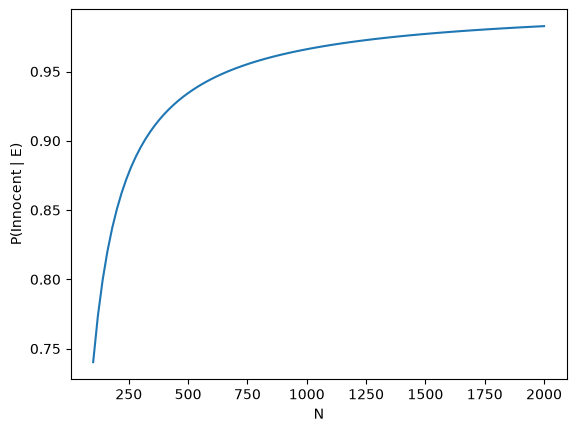

array([0.74027464, 0.77376922, 0.79961161, 0.82015531, 0.83687844,
       0.85075611, 0.86245761, 0.8724576 , 0.88110205, 0.88864909,
       0.89529522, 0.90119267, 0.9064612 , 0.91119632, 0.91547514,
       0.91936058, 0.92290451, 0.92615006, 0.92913338, 0.93188503,
       0.93443098, 0.93679346, 0.93899163, 0.94104203, 0.9429591 ,
       0.94475543, 0.94644206, 0.94802877, 0.94952416, 0.9509359 ,
       0.95227082, 0.95353503, 0.954734  , 0.95587264, 0.95695541,
       0.95798631, 0.95896899, 0.95990675, 0.9608026 , 0.9616593 ,
       0.96247935, 0.96326505, 0.96401852, 0.9647417 , 0.96543639,
       0.96610423, 0.96674675, 0.96736537, 0.96796139, 0.96853603,
       0.96909042, 0.96962561, 0.97014258, 0.97064225, 0.97112548,
       0.97159305, 0.97204572, 0.97248419, 0.97290911, 0.97332112,
       0.97372077, 0.97410863, 0.97448521, 0.97485099, 0.97520644,
       0.97555197, 0.97588801, 0.97621493, 0.97653311, 0.97684288,
       0.97714459, 0.97743853, 0.97772501, 0.97800431, 0.97827

In [47]:
import numpy as np
import matplotlib.pyplot as plt

Ns = np.arange(100, 2001, 20)
p_innocent_vs_N = Ns * p_streak / (1 + Ns * p_streak)  # vectorised in Ns and p_streak
# plot; label axes N and P(Innocent | E)
plt.plot(Ns, p_innocent_vs_N)
plt.xlabel('N')
plt.ylabel('P(Innocent | E)')   
plt.show()
# pip install numpy matplotlib if an import fails
p_innocent_vs_N


In [48]:
import numpy as np
assert np.array_equal(np.asarray(Ns), np.arange(100, 2001, 20)), "use Ns = np.arange(100, 2001, 20)"
assert p_innocent_vs_N is not None, "replace None"
p_innocent_vs_N = np.asarray(p_innocent_vs_N, dtype=float)
assert len(p_innocent_vs_N) == len(Ns)
check("p_innocent_n100", float(p_innocent_vs_N[0]), "998b3d3d0be1ed14")
check("p_innocent_n500_curve", float(p_innocent_vs_N[np.where(np.asarray(Ns) == 500)[0][0]]), "86cd8568d2f8bd16")
check("p_innocent_n2000", float(p_innocent_vs_N[-1]), "58179073542bfc75")
assert np.all(np.diff(p_innocent_vs_N) > 0), "posterior of innocence should rise with N"
print("ok  exercise 9 plot")


ok  p_innocent_n100
ok  p_innocent_n500_curve
ok  p_innocent_n2000
ok  exercise 9 plot


Kramnik quotes $p=P(E\mid I)\approx 3\%$ as if that were the chance Nakamura cheated. What probability is that, and what probability did we compute instead?

**That is the probability that someone produced the streak if they are innocent. The number we computed was the probability someone is innocent if they produced the streak.**  

Pick two of the four modeling choices. For each, say which way $P(I\mid E)$ would move if you relaxed it (toward innocent, toward cheating, or you cannot tell without more structure). Two to four sentences.

**The first modeling choice would move $P(I\mid E)$ more toward innocent, weakening the case for cheating because 1 is the highest $P(E\mid G)=1$ can go. The third modeling choice would also cause $P(I\mid E)$ to move more toward innocent because if games are independent then the player would not be shaken after a loss and therefore is more likely to win the next game than if they were shaken from the loss.**  

Look at the plot. At $N=100$, is $P(I\mid E)$ already most of the way to Anand, or does $N=10{,}000$ do the remaining work? One sentence.

**The N=10,000 does the remaining work.**


## Disclose

What did you use (tutor, Cursor, ChatGPT, a classmate, nothing) and for which parts?

**I used the tutor to help disect the questions and check answers. I used it almost entirely to answer exercise 9.**